# Web Scraping

Lots of great data is available online, but available through inconveniently formatted web pages. When this is the case, sometimes you can simply copy and paste the data into a .csv file and go on with your life. But if there are many records to parse and combine into a dataset, that might be impossible. Can we automate the collection of data from online sources?

This is called web scraping. Broadly speaking: Web scraping is legal, but what you plan to do with the results of your scraping might not be. In general, most sites do not want you to scrape them at this point, but there is not really a way to stop you if you are sufficiently motivated. Be careful to use server resources respectfully (not too many requests per unit time), think seriously about privacy concerns, and be careful who you share your work with and how it is used.

We'll be scraping data about used cars in Charlottesville from Craigslist, particularly this page: https://charlottesville.craigslist.org/search/cta?purveyor=owner#search=1~gallery~0~0

We'll use the `requests` package to get web pages off the Internet and into Python. Again, we'll use a header with a user-agent that masks our true identity so that we're not rejected by the server. This particular url points to the car listings for Craigslist in Charlottesville. To use requests, you pass a `url` for the page you want and a `header` that controls how you appear to the server to `requests.get`:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import requests # Page requests

header = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:124.0) Gecko/20100101 Firefox/124.0'} # How we wish to appear to CL
url = 'https://charlottesville.craigslist.org/search/cta?purveyor=owner#search=1~gallery~0~0' # The page we want to scrape
raw = requests.get(url,headers=header) # Get page

Now that we have that particular page available locally, we want to **parse** it and get results from it. To do that, we can use a package called `beautifulSoup` or `bs4`.

What does `beautifulSoup` do for us? Let's go to the web page of interest. You probably see something like this:

![Listings](./src/craigslist.png "Craigslist")

But if you "view page source" -- which is CTRL+U -- in Chrome, you see what the computer sees:

![Listings](./src/craigslist_source.png "Craigslist")

Since your web browser needs lots of instructions about how to render the text, pictures, and other content on your web page, there are a lot of clues about where the data live and how to extricate them from a page. These clues are called **tags**. If you wander the source for the search page on cars, you see a particular `class = "cl-static-search-result"` term appear attached to each listing:

![Listings](./src/listing.png "Craigslist")

This structure can be exploited to search the page for information. This kind of detective work -- looking at the page source, finding the interesting tags, and then searching the page with `beautifulSoup` -- is the basic job of web scraping.

What I do is look at the rendered page, find the text I want and copy it, then search for that text in the HTML code that the computer sees. When I find the text I want, I look for the tag nearby. Here, it's `cl-static-search-result`: That's what I'll want beautifulSoup to search for.

The following code chunk takes the raw content from `requests` and turns it into a beautifulSoup object, which can search the page and return results for us:

In [ ]:
from bs4 import BeautifulSoup as soup # HTML parser
bsObj = soup(raw.content,'html.parser') # Parse the html
listings = bsObj.find_all(class_="cl-static-search-result") # Find all listings of the kind we want

Why is the argument `class_` and not just `class`? The word `class` is a reserved keyword for Python, and cannot be used by anyone else, similar to `True` and `False`. But since we want the `class = "cl-static-search-result"` terms, we need to use the `class_` argument to the `.find_all` method.

The `.find_all` function dredges the entire page and finds all the instances of `class = "cl-static-search-result"`, resulting in a list of entries. We can then parse the entries.

Parsing the entries can be a challenge! We have to go back to what a listing looks like, and look at the tags within the listing. They're typically `div` tags with a `class` like price or location. You then have to experiment a bit with `.find` and the HTML to make sure you're getting the information you want. For each listing, the `.find` method to search within the listing record for specific information, but it's typically still wrapped in the tag. To get the real information we want, we can then use `.get_text()`. I end up using a code chunk to experiment and play with a record to make sure I'm getting as close to what I want as possible.

In the code below, two more things happen. You don't need to do them in your work, but they're helpful to know about.

First, I would like to get the brand of the car from the post title, if possible. To do this, I split the title into words using `title.split()`, and then I use a list comprehension to look over every word in the title and check whether it appears in the `brands` list.

Second, I would like to get the year the car was built, if possible, so I can determine the vehicle's age. To do this, I use a thing called **regular expressions** that provides a language for expressing patterns. Do I remember how to do this off the top of my head? No, I read a few pages in a book and looked on StackOverflow for answers. Roughly, in order to express the idea "any year starting with 20xx," you can write `20[0-9][0-9]`, and for "any year starting with 19xx," you can write `19[0-9][0-9]`. The `[0-9]`'s act as wildcards for any digit. This allows me to use the `re` package to find any instances of year-like numbers in the title text, using `re.search(r'20[0-9][0-9]|19[0-9][0-9]', title )`.

This is all nested in a for-loop over the listings, and the data is appended to a list.

In [ ]:
import re # Regular expressions

brands = ['honda', 'dodge','toyota','ford','tesla','gmc','jeep','bmw','mitsubishi','mazda',
          'volvo','audi','volkswagen','chevy','chevrolet','acura','kia','subaru','lexus',
          'cadillac','buick','porsche','infiniti']

data = [] # We'll save our listings in this object
for k in range( len(listings) ):
    title = listings[k].find('div',class_='title').get_text().lower()
    price = listings[k].find('div',class_='price').get_text()
    link = listings[k].find(href=True)['href']
    # Get brand from the title string:
    words = title.split()
    hits = [word for word in words if word in brands] # Find brands in the title
    if len(hits) == 0:
        brand = 'missing'
    else:
        brand = hits[0]
    # Get years from title string:
    regex_search = re.search(r'20[0-9][0-9]|19[0-9][0-9]', title ) # Find year references
    if regex_search is None: # If no hits, record year as missing value
        year = np.nan
    else: # If hits, record year as first match
        year = regex_search.group(0)
    #
    data.append({'title':title,'price':price,'year':year,'link':link,'brand':brand})


With the data scraped from Craigslist, we can put it in a dataframe and wrangle it. Of course, price and year come in as text, not numbers, and need to be typecast/coerced:

In [ ]:
## Wrangle the data
df = pd.DataFrame.from_dict(data)
df['price'] = df['price'].str.replace('$','')
df['price'] = df['price'].str.replace(',','')
df['price'] = pd.to_numeric(df['price'],errors='coerce')
df['year'] = pd.to_numeric(df['year'],errors='coerce')
df['age'] = 2025-df['year']
print(df.shape)
df.to_csv('./src/craigslist_cville_cars.csv') # Save data in case of a disaster
df.head()

(46, 6)


,title,price,year,link,brand,age
0,a sweet sedan avalon xle plus,24000,NaN,https://charlottesville.craigslist.org/cto/d/c...,missing,NaN
1,"1998 gmc sierra 1500 sl truck auto rwd <103,00...",6950,1998.0,https://charlottesville.craigslist.org/cto/d/l...,gmc,27.0
2,gmc sierra 3500hd 6.6 duramax diesel dually,26000,NaN,https://charlottesville.craigslist.org/cto/d/c...,gmc,NaN
3,2007 chrysler sebring,2900,2007.0,https://charlottesville.craigslist.org/cto/d/c...,missing,18.0
4,2012 nissan versa sl,3500,2012.0,https://charlottesville.craigslist.org/cto/d/c...,missing,13.0


With the data in and wrangled, we can now do some analysis:

count       46.000000
mean     11983.630435
std      13656.112410
min       2000.000000
25%       4037.500000
50%       6725.000000
75%      13350.000000
max      62800.000000
Name: price, dtype: float64


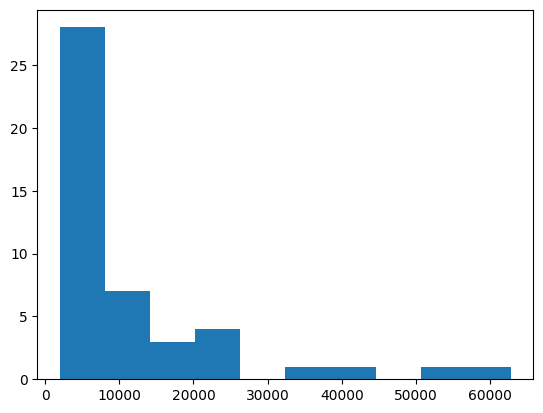

count    41.000000
mean     24.121951
std      16.315936
min       6.000000
25%      13.000000
50%      19.000000
75%      31.000000
max      68.000000
Name: age, dtype: float64


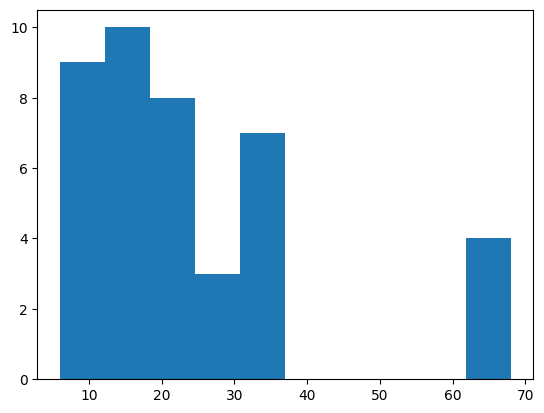

In [ ]:
print(df['price'].describe())
df['price'].hist(grid=False)
plt.show()
print(df['age'].describe())
df['age'].hist(grid=False)
plt.show()

In [ ]:
# Price by brand:
df.loc[:,['price','brand']].groupby('brand').describe()

price                                                          \
           count          mean           std      min       25%      50%   
brand                                                                      
audi         1.0  37000.000000           NaN  37000.0  37000.00  37000.0   
bmw          3.0  19966.666667  20813.537261   7900.0   7950.00   8000.0   
chevrolet    4.0  10875.000000   9393.038202   3000.0   3375.00   9000.0   
chevy        3.0  11616.666667  11515.677719   4450.0   4975.00   5500.0   
dodge        1.0  18900.000000           NaN  18900.0  18900.00  18900.0   
ford         3.0  21333.333333  29173.332572   3500.0   4500.00   5500.0   
gmc          2.0  16475.000000  13470.384182   6950.0  11712.50  16475.0   
honda        5.0   5629.800000   2372.328013   2300.0   4700.00   5900.0   
jeep         2.0   9500.000000      0.000000   9500.0   9500.00   9500.0   
lexus        2.0  11175.000000    318.198052  10950.0  11062.50  11175.0   
missing     14.0  10089.214286  16148.241324   2000.0   3312.50   4650.0   
mitsubishi   1.0   7300.000000           NaN   7300.0   7300.00   7300.0   
subaru       1.0   3900.000000           NaN   3900.0   3900.00   3900.0   
toyota       4.0   9549.750000   7072.121340   2199.0   4299.75   9500.0   

                               
                 75%      max  
brand                          
audi        37000.00  37000.0  
bmw         26000.00  44000.0  
chevrolet   16500.00  22500.0  
chevy       15200.00  24900.0  
dodge       18900.00  18900.0  
ford        30250.00  55000.0  
gmc         21237.50  26000.0  
honda        6500.00   8749.0  
jeep         9500.00   9500.0  
lexus       11287.50  11400.0  
missing      6749.75  62800.0  
mitsubishi   7300.00   7300.0  
subaru       3900.00   3900.0  
toyota      14750.00  17000.0

In [ ]:
# Age by brand:
df.loc[:,['age','brand']].groupby('brand').describe()

age                                                    
           count       mean        std   min   25%   50%   75%   max
brand                                                               
audi         1.0   6.000000        NaN   6.0   6.0   6.0   6.0   6.0
bmw          2.0  15.000000   1.414214  14.0  14.5  15.0  15.5  16.0
chevrolet    4.0  44.000000  16.000000  36.0  36.0  36.0  44.0  68.0
chevy        3.0  20.000000  12.124356   7.0  14.5  22.0  26.5  31.0
dodge        1.0  27.000000        NaN  27.0  27.0  27.0  27.0  27.0
ford         3.0  22.666667   1.154701  22.0  22.0  22.0  23.0  24.0
gmc          1.0  27.000000        NaN  27.0  27.0  27.0  27.0  27.0
honda        5.0  18.000000   9.000000  10.0  13.0  15.0  19.0  33.0
jeep         2.0  22.000000  14.142136  12.0  17.0  22.0  27.0  32.0
lexus        2.0  17.000000   5.656854  13.0  15.0  17.0  19.0  21.0
missing     11.0  30.636364  23.585049   7.0  12.0  20.0  49.0  68.0
mitsubishi   1.0  17.000000        NaN  17.0  17.0  17.0  17.0  17.0
subaru       1.0  11.000000        NaN  11.0  11.0  11.0  11.0  11.0
toyota       4.0  15.500000   3.109126  12.0  13.5  15.5  17.5  19.0

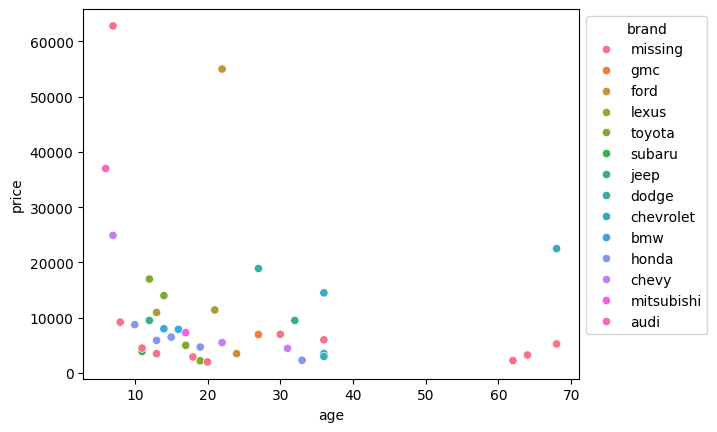

In [ ]:
ax = sns.scatterplot(data=df, x='age', y='price',hue='brand')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

           log_price   log_age
log_price   0.783367 -0.196806
log_age    -0.196806  0.382606
           log_price   log_age
log_price   1.000000 -0.376511
log_age    -0.376511  1.000000


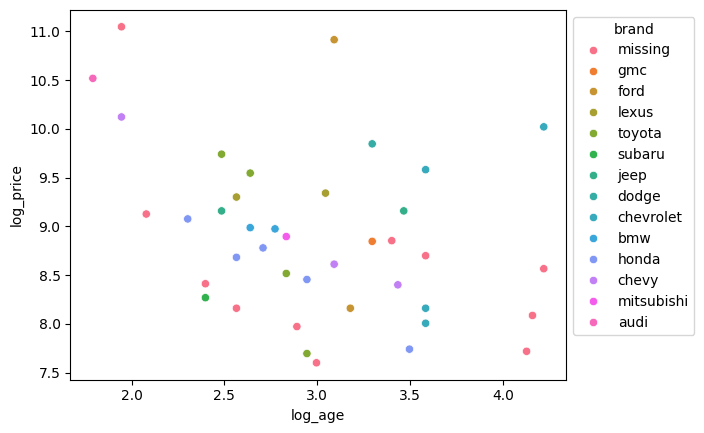

In [ ]:
df['log_price'] = np.log(df['price'])
df['log_age'] = np.log(df['age'])

ax = sns.scatterplot(data=df, x='log_age', y='log_price',hue='brand')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

print(df.loc[:,['log_price','log_age']].cov())
print(df.loc[:,['log_price','log_age']].corr())

## The Lab:


1. Pick something else on Craigslist besides used cars: Musical instruments, roommates, antiques, etc. Look at the search page and its source code. Record which fields/data you would like to gather, and what kinds of basic EDA you'd do with it.
2. Get your search results of interest using `requests` and extract data from them using `beautifulSoup`, using code similar to what's above.
3. Wrangle your data into a dataframe and do some basic descriptions and plots. Try to find some interesting relationships or stories to tell about your data.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from bs4 import BeautifulSoup as soup
import requests
import re

header = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:124.0) Gecko/20100101 Firefox/124.0'}
url = 'https://charlottesville.craigslist.org/search/bia#search=1~gallery~0~0'
raw = requests.get(url, headers=header)

In [3]:
bsObj = soup(raw.content, 'html.parser')
listings = bsObj.find_all(class_="cl-static-search-result")
print(f"Found {len(listings)} bicycle listings")

Found 25 bicycle listings


In [4]:
bike_types = ['mountain', 'road', 'hybrid', 'cruiser', 'bmx', 'electric',
              'gravel', 'fixie', 'single-speed', 'touring', 'folding',
              'specialized', 'trek', 'cannondale', 'giant', 'scott',
              'bianchi', 'cervelo', 'salsa', 'surly', 'kona']

data = []
for k in range(len(listings)):
    try:
        title_elem = listings[k].find('div', class_='title')
        title = title_elem.get_text().lower() if title_elem else 'missing'

        price_elem = listings[k].find('div', class_='price')
        price = price_elem.get_text() if price_elem else 'missing'

        location_elem = listings[k].find('div', class_='location')
        location = location_elem.get_text() if location_elem else 'missing'

        link_elem = listings[k].find('a', href=True)
        link = link_elem['href'] if link_elem else 'missing'

        words = title.split()
        hits = [word for word in words if word in bike_types]
        if len(hits) == 0:
            bike_type = 'other'
        else:
            bike_type = hits[0]

        regex_search = re.search(r'20[0-9][0-9]|19[0-9][0-9]', title)
        if regex_search is None:
            year = np.nan
        else:
            year = regex_search.group(0)

        size_search = re.search(r'(\d+["\']?)', title)
        frame_size = size_search.group(0) if size_search else 'unknown'

        data.append({
            'title': title,
            'price': price,
            'location': location,
            'link': link,
            'bike_type': bike_type,
            'year': year,
            'frame_size': frame_size
        })

    except Exception as e:
        print(f"Error processing listing {k}: {e}")
        continue

In [5]:
df = pd.DataFrame.from_dict(data)
print(f"Created DataFrame with {len(df)} rows")
print(df.head())

df['price_clean'] = df['price'].str.replace('$', '', regex=False)
df['price_clean'] = df['price_clean'].str.replace(',', '', regex=False)
df['price_clean'] = pd.to_numeric(df['price_clean'], errors='coerce')

df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['age'] = 2025 - df['year']

df['frame_size_numeric'] = df['frame_size'].str.extract(r'(\d+\.?\d*)')
df['frame_size_numeric'] = pd.to_numeric(df['frame_size_numeric'], errors='coerce')

print("\n--- Data after cleaning ---")
print(df[['title', 'price_clean', 'bike_type', 'year', 'age', 'frame_size_numeric']].head())

Created DataFrame with 25 rows
                                               title   price  \
0                ci2 litespeed ultegra di2 bike 2019  $1,300   
1                    soma doublecross cx bike loaded    $595   
2  jamis dragon one single speed 29er mountain bi...  $2,200   
3                        specialized road bike.  obo    $150   
4                                      razor scooter     $90   

                                            location  \
0  \n                        Ruckersville\n      ...   
1  \n                        Schuyler\n          ...   
2  \n                        Nellysford\n        ...   
3  \n                        Zion Crossroads\n   ...   
4                                            missing   

                                                link    bike_type  year  \
0  https://charlottesville.craigslist.org/bik/d/q...        other  2019   
1  https://charlottesville.craigslist.org/bik/d/s...        other   NaN   
2  https://charlottesv

In [6]:
print("\nBASIC STATISTICS")

print("\n1. Price Statistics:")
print(df['price_clean'].describe())

print("\n2. Bike Type Distribution:")
print(df['bike_type'].value_counts())

print("\n3. Age Statistics (for bikes with year):")
print(df['age'].describe())

print("\n4. Frame Size Statistics:")
print(df['frame_size_numeric'].describe())


BASIC STATISTICS

1. Price Statistics:
count      25.00000
mean      810.96000
std      1276.06529
min        15.00000
25%        90.00000
50%       250.00000
75%      1250.00000
max      6000.00000
Name: price_clean, dtype: float64

2. Bike Type Distribution:
bike_type
other          13
trek            5
mountain        2
specialized     1
road            1
cannondale      1
cervelo         1
cruiser         1
Name: count, dtype: int64

3. Age Statistics (for bikes with year):
count    2.000000
mean     3.500000
std      3.535534
min      1.000000
25%      2.250000
50%      3.500000
75%      4.750000
max      6.000000
Name: age, dtype: float64

4. Frame Size Statistics:
count      12.000000
mean      178.000000
std       581.415358
min         2.000000
25%         2.750000
50%         7.000000
75%        18.750000
max      2024.000000
Name: frame_size_numeric, dtype: float64


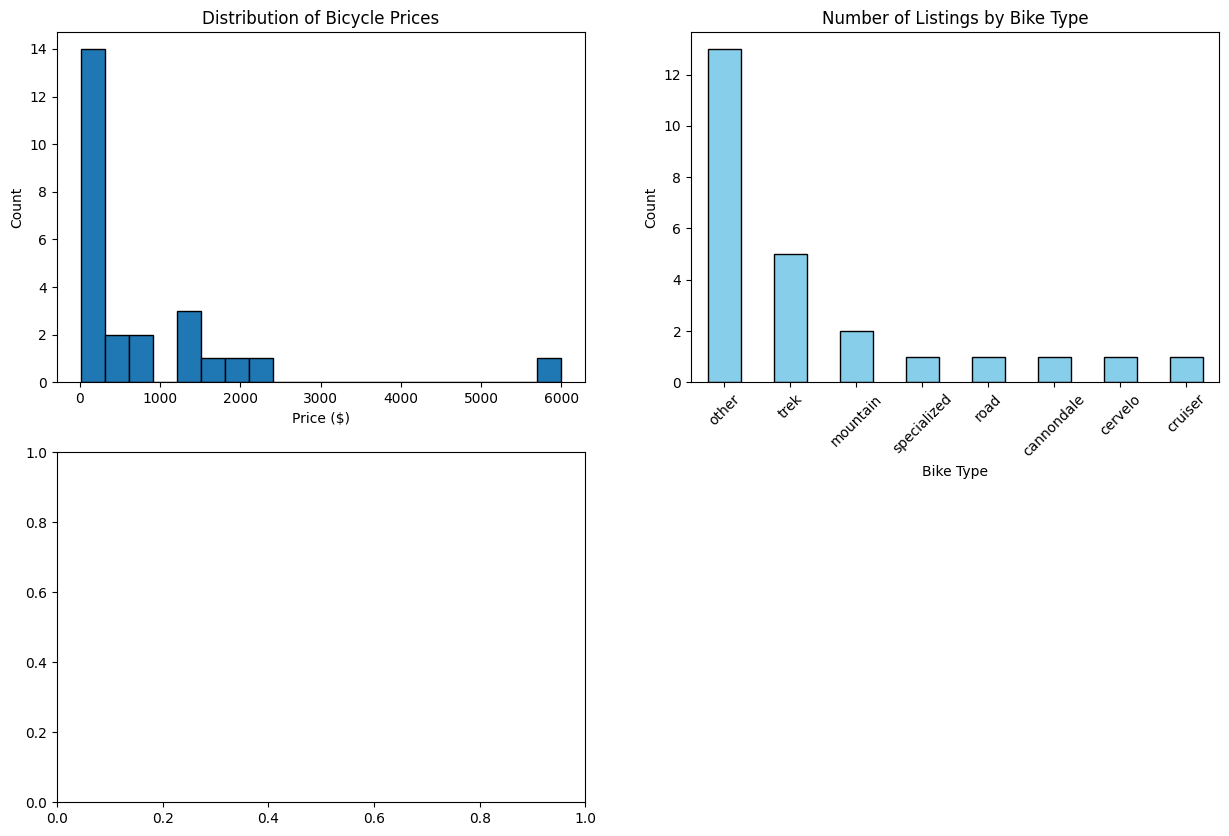

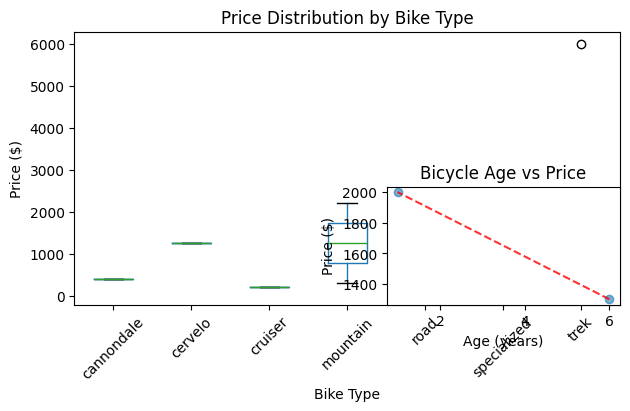

In [9]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
df['price_clean'].hist(bins=20, grid=False, edgecolor='black')
plt.title('Distribution of Bicycle Prices')
plt.xlabel('Price ($)')
plt.ylabel('Count')

plt.subplot(2, 2, 2)
df['bike_type'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Listings by Bike Type')
plt.xlabel('Bike Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)
df_filtered = df[df['bike_type'] != 'other']
if len(df_filtered) > 0:
    df_filtered.boxplot(column='price_clean', by='bike_type', grid=False)
    plt.title('Price Distribution by Bike Type')
    plt.suptitle('')
    plt.xlabel('Bike Type')
    plt.ylabel('Price ($)')
    plt.xticks(rotation=45)
else:
    plt.text(0.5, 0.5, 'No specific bike types found\n(all categorized as "other")',
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Price Distribution by Bike Type')

plt.subplot(2, 2, 4)
valid_data = df.dropna(subset=['age', 'price_clean'])
if len(valid_data) > 0:
    plt.scatter(valid_data['age'], valid_data['price_clean'], alpha=0.6)
    plt.title('Bicycle Age vs Price')
    plt.xlabel('Age (years)')
    plt.ylabel('Price ($)')
    if len(valid_data) > 1:
        z = np.polyfit(valid_data['age'], valid_data['price_clean'], 1)
        p = np.poly1d(z)
        plt.plot(valid_data['age'], p(valid_data['age']), "r--", alpha=0.8)
else:
    plt.text(0.5, 0.5, 'Insufficient data for age vs price analysis',
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('Bicycle Age vs Price')

plt.tight_layout()
plt.show()

In [8]:
print("\nADDITIONAL INFO")

print("\n1. Average Price by Bike Type:")
price_by_type = df.groupby('bike_type')['price_clean'].agg(['count', 'mean', 'std', 'min', 'max'])
print(price_by_type)

if len(df.dropna(subset=['age', 'price_clean'])) > 1:
    correlation = df['age'].corr(df['price_clean'])
    print(f"\n2. Correlation between age and price: {correlation:.3f}")
    if correlation < 0:
        print("   Interpretation: Older bikes tend to be cheaper (negative correlation)")
    else:
        print("   Interpretation: No clear relationship between age and price")

print("\n3. Top 5 Most Expensive Bikes:")
top_expensive = df.nlargest(5, 'price_clean')[['title', 'price_clean', 'bike_type', 'age']]
print(top_expensive)

print("\n4. Top 5 Cheapest Bikes:")
top_cheap = df.nsmallest(5, 'price_clean')[['title', 'price_clean', 'bike_type', 'age']]
print(top_cheap)

print("\n5. Location Analysis:")
print(df['location'].value_counts().head())

df.to_csv('craigslist_cville_bicycles.csv', index=False)
print("\nData saved to 'craigslist_cville_bicycles.csv'")


ADDITIONAL INFO

1. Average Price by Bike Type:
             count         mean          std   min   max
bike_type                                               
cannondale       1   400.000000          NaN   400   400
cervelo          1  1250.000000          NaN  1250  1250
cruiser          1   200.000000          NaN   200   200
mountain         2  1250.000000  1343.502884   300  2200
other           13   557.307692   706.601654    15  2000
road             1    80.000000          NaN    80    80
specialized      1   150.000000          NaN   150   150
trek             5  1689.800000  2474.569700   100  6000

2. Correlation between age and price: -1.000
   Interpretation: Older bikes tend to be cheaper (negative correlation)

3. Top 5 Most Expensive Bikes:
                                                title  price_clean bike_type  \
23                  trek supercaliber slr gen 2 large         6000      trek   
2   jamis dragon one single speed 29er mountain bi...         2200  mo

# **"Analysis"**
Category: Bicycles aka /bia

Collected:
- title: Description of bike
- price: Listing price
- location: Area/neighborhood in Charlottesville
- link: URL to listing
- bike_type: Categorized type of bike
- year: Manufacturing year, taken from title
- age: Calculated age of bike using 2025-year
- frame_size: Approximate frame size

HTML Structure
- Container class: cl-static-search-result
- Sub-elements: div.title, div.price, div.location
- Pattern: This structure seems to be consistent across various Craigslist categories

Planned EDA:
- Price distribution analysis
- Bike type frequency counts
- Age vs price relationship
- Location patterns
- Frame size analysis


#  **Interesting Findings**
1. Based on the visualizations, bikes show a right-skewed price distribution. Most bikes are under 2k.
2. Mountain bikes appear most frequently.
3. There is a negative correlation between age and price, which makes sense considering depreciaton.
4. Many of the listings do not have the manufacturing year information.